<a href="https://colab.research.google.com/github/bberrium/Picsart-Academy/blob/main/Phase%203/DS/projects/houses_price_model/houses_price_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yerevan House Price Prediction

In [17]:
import sys
import subprocess

# Mapping: { import_name: pip_package_name }
packages = {
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "sklearn": "scikit-learn",
    "joblib": "joblib"
}

for module_name, pip_name in packages.items():
    try:
        __import__(module_name)
    except ImportError:
        print(f"Library '{module_name}' not found. Installing '{pip_name}'...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

print("Everything is installed!")

Everything is installed!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (cross_validate, cross_val_score, KFold,
                                      RepeatedKFold, RandomizedSearchCV, train_test_split)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [19]:
df = pd.read_csv('houses_train.csv')
print(df.shape)
df.head()

(5001, 14)


,Unnamed: 0,price,condition,district,max_floor,street,num_rooms,region,area,url,num_bathrooms,building_type,floor,ceiling_height
0,4598,100000.0,newly repaired,Arabkir,6,Kievyan St,3,Yerevan,96.0,http://www.myrealty.am/en/item/26229/3-senyaka...,1,stone,4,3.0
1,5940,52000.0,good,Arabkir,14,Mamikoniants St,3,Yerevan,78.0,http://www.myrealty.am/en/item/32897/3-senyaka...,1,panel,10,2.8
2,2302,52000.0,newly repaired,Qanaqer-Zeytun,9,M. Melikyan St,3,Yerevan,97.0,http://www.myrealty.am/en/item/1459/apartment-...,1,panel,1,2.8
3,5628,130000.0,good,Center,4,Spendiaryan St,3,Yerevan,80.0,http://www.myrealty.am/en/item/2099/3-senyakan...,1,stone,2,3.2
4,760,81600.0,zero condition,Center,9,Ler. Kamsar St,3,Yerevan,107.0,http://www.myrealty.am/en/item/22722/3-senyaka...,1,monolit,9,3.0


## 1. Outlier handling — per-district winsorizing

In [20]:
def winsorize_per_group(series, group, lower=0.01, upper=0.99):
    bounds = pd.DataFrame({'v': series, 'g': group}).groupby('g')['v'].quantile([lower, upper]).unstack()
    print("=== STEP 1: Combine into a temporary DataFrame ===")
    step1 = pd.DataFrame({'v': series, 'g': group})
    print(step1)
    print("\n" + "="*50 + "\n")

    print("=== STEP 2: Group by 'g' (district) ===")
    print("Data is now split into separate groups internally:")
    for g_name, g_df in step1.groupby('g'):
        print(f"Group '{g_name}':\n{g_df['v'].tolist()}")
    print("\n" + "="*50 + "\n")

    print("=== STEP 3: Calculate quantiles per group ===")
    step3 = step1.groupby('g')['v'].quantile([lower, upper])
    print(step3)
    print("\nNotice the MultiIndex output (District, Quantile Level)!")
    print("\n" + "="*50 + "\n")

    print("=== STEP 4: .unstack() to widen into columns ===")
    bounds = step3.unstack()
    print(bounds)
    print("\nNow lower and upper are column headers!")

# BEFORE .unstack()                    AFTER .unstack()
# (MultiIndex Series)                  (2D DataFrame)

#   Group   Quantile    Value
#  ┌──────┬──────────┬────────┐           Quantile ──>  0.01    0.99
#  │North │   0.01   │  51.5  │           Group (g) ┌───────┬───────┐
#  │      │   0.99   │ 275.5  │  ──────>  North     │ 51.5  │ 275.5 │
#  ├──────┼──────────┼────────┤           South     │ 13.5  │  49.5 │
#  │South │   0.01   │  13.5  │                     └───────┴───────┘
#  │      │   0.99   │  49.5  │
#  └──────┴──────────┴────────┘

    lo = group.map(bounds[lower])
    hi = group.map(bounds[upper])

# Original 'group'        bounds[0.01] Lookup        Resulting 'lo' Series
#   (df['district'])          (District -> Limit)       (Row-by-Row Lower Limits)

# 0    North                  North  ->  51.5          0    51.5
# 1    North     .map()       South  ->  13.5          1    51.5
# 2    North   ─────────>                              2    51.5
# 3    South                                           3    13.5
# 4    South                                           4    13.5

    return series.clip(lower=lo, upper=hi)

df['area'] = winsorize_per_group(df['area'], df['district'])
df['price'] = winsorize_per_group(df['price'], df['district'])

=== STEP 1: Combine into a temporary DataFrame ===
          v               g
0      96.0         Arabkir
1      78.0         Arabkir
2      97.0  Qanaqer-Zeytun
3      80.0          Center
4     107.0          Center
...     ...             ...
4996   97.0         Arabkir
4997   71.0         Arabkir
4998   40.0          Center
4999  118.0          Center
5000   75.0         Arabkir

[5001 rows x 2 columns]


=== STEP 2: Group by 'g' (district) ===
Data is now split into separate groups internally:
Group 'Achapnyak':
[42.0, 51.0, 111.0, 109.0, 76.0, 58.0, 65.0, 95.0, 50.0, 74.0, 96.0, 45.0, 78.0, 40.0, 66.0, 81.0, 60.0, 79.0, 54.0, 55.0, 65.0, 72.0, 50.0, 81.0, 123.0, 68.0, 75.0, 104.0, 51.0, 92.0, 71.0, 96.0, 45.0, 67.0, 95.0, 76.0, 65.0, 40.0, 64.0, 126.0, 80.0, 46.0, 104.0, 38.0, 65.0, 55.0, 52.0, 66.0, 93.0, 63.0, 60.0, 40.0, 48.0, 95.0, 49.0, 78.0, 82.0, 86.0, 62.0, 93.0, 57.0, 80.0, 70.0, 54.0, 58.0, 52.0, 58.0, 44.0, 70.0, 61.0, 71.0, 75.0, 60.0, 50.0, 78.0, 89.0, 85.0, 84.0, 8

Plotting Price Distribution by District...


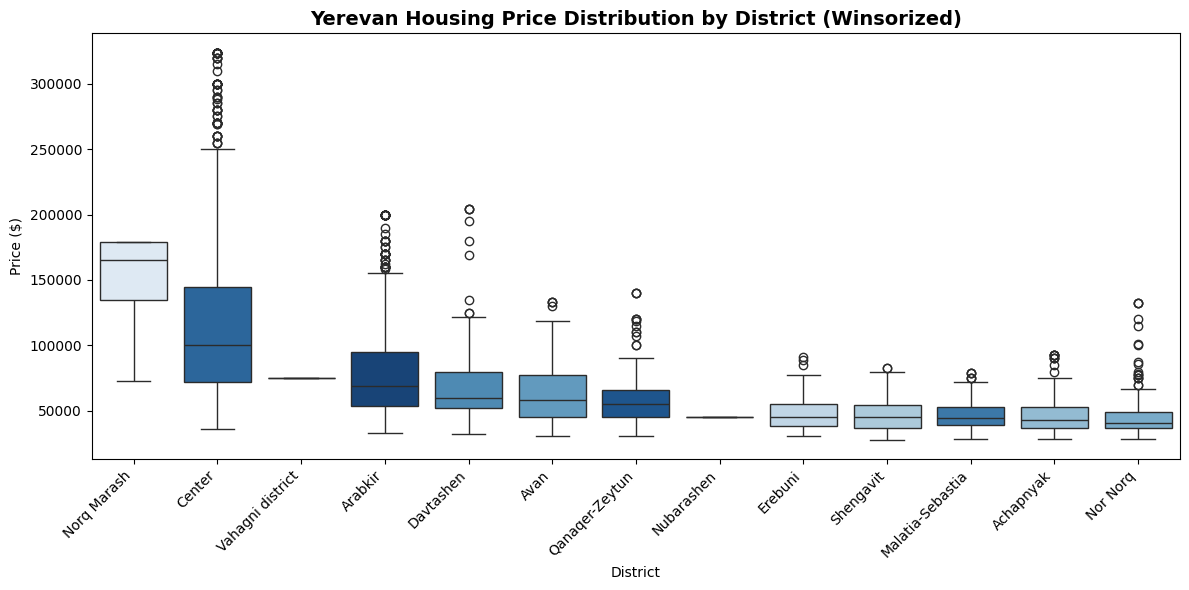

In [21]:
print("Plotting Price Distribution by District...")
plt.figure(figsize=(12, 6))
order = df.groupby('district')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='district', y='price', order=order, hue='district', palette='Blues_r', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Yerevan Housing Price Distribution by District (Winsorized)', fontsize=14, fontweight='bold')
plt.ylabel('Price ($)')
plt.xlabel('District')
plt.tight_layout()
plt.show()

In [22]:
def engineer(df):
    df = df.copy()
    df['room_size'] = df['area'] / df['num_rooms'].replace(0, 1)
    df['floor_ratio'] = df['floor'] / df['max_floor'].replace(0, 1)
    df['is_top_floor'] = (df['floor'] == df['max_floor']).astype(int)
    df['is_ground_floor'] = (df['floor'] <= 1).astype(int)
    df['bath_per_room'] = df['num_bathrooms'] / df['num_rooms'].replace(0, 1)
    df['log_area'] = np.log1p(df['area'])
    df['ceiling_area'] = df['ceiling_height'] * df['area']
    df['district_building'] = df['district'].astype(str) + '_' + df['building_type'].astype(str)
    return df

df = engineer(df)
print(df)
print("floor == 0 (ground?):", (df['floor'] == 0).sum())

      Unnamed: 0     price       condition        district  max_floor  \
0           4598  100000.0  newly repaired         Arabkir          6   
1           5940   52000.0            good         Arabkir         14   
2           2302   52000.0  newly repaired  Qanaqer-Zeytun          9   
3           5628  130000.0            good          Center          4   
4            760   81600.0  zero condition          Center          9   
...          ...       ...             ...             ...        ...   
4996        3585   70000.0  newly repaired         Arabkir          5   
4997        3291   77000.0  newly repaired         Arabkir          4   
4998        5959   46000.0  zero condition          Center          5   
4999         542   99000.0  newly repaired          Center         14   
5000        4593  100000.0  newly repaired         Arabkir          5   

                       street  num_rooms   region   area  \
0                  Kievyan St          3  Yerevan   96.0   
1  

## 2. Feature engineering
added:
- `is_ground_floor` — floor <= 1 (also floor==0)
- `bath_per_room` bathroom/room relations
- `log_area` — (useful for Ridge, target is logged in pipeline)
- `ceiling_area` — ceiling_height × area (most importatant feature by permutation importance)
- `district_building` — district × building_type

In [23]:
X = df.drop(columns=['price', 'url'], errors='ignore')
y = df['price']

num_cols = ['max_floor', 'num_rooms', 'area', 'num_bathrooms', 'floor', 'ceiling_height',
            'room_size', 'floor_ratio', 'is_top_floor', 'is_ground_floor', 'bath_per_room',
            'log_area', 'ceiling_area']
cat_low_card = ['condition', 'district', 'region', 'building_type', 'district_building']
cat_high_card = ['street']  # Target Encoded (350+ unique values)

In [24]:
preprocessor = ColumnTransformer(transformers=[
    ('num_pipeline', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_cols),

    ('cat_low_pipeline', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_low_card),

    ('cat_high_pipeline', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('target_enc', TargetEncoder(target_type='continuous', random_state=42))
    ]), cat_high_card)
])

In [25]:
X.columns.to_list()

['Unnamed: 0',
 'condition',
 'district',
 'max_floor',
 'street',
 'num_rooms',
 'region',
 'area',
 'num_bathrooms',
 'building_type',
 'floor',
 'ceiling_height',
 'room_size',
 'floor_ratio',
 'is_top_floor',
 'is_ground_floor',
 'bath_per_room',
 'log_area',
 'ceiling_area',
 'district_building']

## 3. Model comparison — R², RMSE, MAE

In [26]:
models_to_test = {
    'Ridge': RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0, 500.0]),
    'RandomForest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=-1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}

results = {}
for name, model in models_to_test.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    wrapped = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    cv_res = cross_validate(wrapped, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    results[name] = {
        'R2': cv_res['test_r2'].mean(),
        'R2_std': cv_res['test_r2'].std(),
        'MAE': -cv_res['test_mae'].mean(),
        'RMSE': -cv_res['test_rmse'].mean(),
    }
    print(f"{name:12s} R2={results[name]['R2']:.4f} (±{results[name]['R2_std']:.4f})  "
          f"MAE=${results[name]['MAE']:,.0f}  RMSE=${results[name]['RMSE']:,.0f}")

pd.DataFrame(results).T


# When you pass data to pipe.fit(X, y), the Pipeline executes an automated sequence of hands-offs:

# X, y
#         │
#         ▼
# ┌───────────────────────────────┐
# │ 1. 'preprocessor'             │
# │    Runs .fit_transform(X, y)  │ ──> Learns mean/std, imputations, target encodings
# └───────────────┬───────────────┘
#                 │
#                 │ Transformed Matrix (X_transformed)
#                 ▼
# ┌───────────────────────────────┐
# │ 2. 'regressor'                │
# │    Runs .fit(X_transformed, y)│ ──> Learns feature weights / tree splits
# └───────────────────────────────┘


# When making predictions on new, unseen data (like X_test or production inputs), calling pipe.predict(X_new) does something critically different:

# X_new
#         │
#         ▼
# ┌───────────────────────────────┐
# │ 1. 'preprocessor'             │
# │    Runs .transform(X_new)     │ ──> Uses PREVIOUSLY learned scaling/encodings
# └───────────────┬───────────────┘     (Does NOT re-fit or calculate new statistics)
#                 │
#                 │ Transformed Matrix (X_new_transformed)
#                 ▼
# ┌───────────────────────────────┐
# │ 2. 'regressor'                │
# │    Runs .predict(...)         │ ──> Returns final numeric predictions
# └───────────────────────────────┘


# When you run wrapped.fit(X, y), TransformedTargetRegressor intercepts the process and performs three distinct steps:
# Target y (e.g., $300,000)
#                           │
#                           ▼
#              ┌─────────────────────────┐
#              │ 1. Applies func         │
#              │    np.log1p(y)          │
#              └────────────┬────────────┘
#                           │
#                           ▼
#              y_log (e.g., 12.61)
#                           │
#                           ▼
# Features X ───────────────┼──────────────┐
#                           │              │
#                           ▼              ▼
#              ┌─────────────────────────┐
#              │ 2. Calls pipe.fit()     │
#              │    pipe.fit(X, y_log)   │
#              └─────────────────────────┘


# When you call wrapped.predict(X_new) on test or production data, TransformedTargetRegressor ensures your final output is back in real-world units (e.g., actual dollars, not log-dollars):
# Features X_new
#                    │
#                    ▼
#       ┌───────────────────────────┐
#       │ 1. Calls pipe.predict()   │
#       │    log_preds = pipe(...)  │
#       └────────────┬──────────────┘
#                    │
#                    ▼
#        log_preds (e.g., 12.61)
#                    │
#                    ▼
#       ┌───────────────────────────┐
#       │ 2. Applies inverse_func   │
#       │    np.expm1(log_preds)    │
#       └────────────┬──────────────┘
#                    │
#                    ▼
#     Final Predictions (e.g., $300,000)


# Under the hood, cross_validate loops through each of the 5 folds created by kf. For each individual fold, it performs the following exact workflow:
# Full Dataset (X, y)
#     │
#     ├─► Fold 1: [ Test (20%) | Train (80%) ] ──► fit on Train ──► predict on Test
#     ├─► Fold 2: [ Train | Test (20%) | Train ] ──► fit on Train ──► predict on Test
#     ├─► Fold 3: [ Train (80%) | Test (20%) ] ──► fit on Train ──► predict on Test
#     ├─► Fold 4: ...
#     └─► Fold 5: ...

# When all 5 folds complete, cross_validate returns a standard Python dictionary (cv_res) containing arrays of metric scores recorded across the folds:
# {
#     'fit_time': array([1.2, 1.1, 1.3, 1.2, 1.1]),       # Seconds taken to fit each fold
#     'score_time': array([0.05, 0.04, 0.05, 0.04, 0.05]), # Seconds taken to score each fold
#     'test_r2': array([0.901, 0.898, 0.912, 0.905, 0.899]),
#     'test_mae': array([-17200, -18100, -16900, -17500, -17800]),
#     'test_rmse': array([-26800, -28100, -26200, -27400, -27900])
# }

Ridge        R2=0.8023 (±0.0071)  MAE=$14,729  RMSE=$22,573
RandomForest R2=0.8207 (±0.0074)  MAE=$13,872  RMSE=$21,496
XGBoost      R2=0.8257 (±0.0131)  MAE=$13,740  RMSE=$21,174
LightGBM     R2=0.8261 (±0.0129)  MAE=$13,801  RMSE=$21,148


,R2,R2_std,MAE,RMSE
Ridge,0.802347,0.007140,14728.590318,22572.869825
RandomForest,0.820678,0.007416,13872.407158,21495.996503
XGBoost,0.825681,0.013054,13740.195501,21173.912139
LightGBM,0.826087,0.012918,13801.260086,21148.218232


## 4. Stability check — RepeatedKFold
just one 5-fold split has ±0.019 std (a noise)։ We're checking the best models with RepeatedKFold (5×3), to make sure the difference in scores is real and not some split magic.

In [27]:
best_two = sorted(results.items(), key=lambda kv: kv[1]['R2'], reverse=True)[:2]
print("Top-2 by mean R2:", [n for n, _ in best_two])

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
model_lookup = {
    'RandomForest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=-1),
}
for name, _ in best_two:
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_lookup[name])])
    wrapped = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    scores = cross_val_score(wrapped, X, y, cv=rkf, scoring='r2', n_jobs=-1)
    print(f"[RepeatedKFold] {name}: R2={scores.mean():.4f} (±{scores.std():.4f})")

Top-2 by mean R2: ['LightGBM', 'XGBoost']
[RepeatedKFold] LightGBM: R2=0.8271 (±0.0140)
[RepeatedKFold] XGBoost: R2=0.8282 (±0.0128)


## 5. Light hyperparameter tuning
instead of fixed hyperparameters - quick `RandomizedSearchCV` on LightGBM(~5000 rows takes just some seconds)

In [28]:
lgbm_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))])
wrapped = TransformedTargetRegressor(regressor=lgbm_pipe, func=np.log1p, inverse_func=np.expm1)

param_dist = {
    'regressor__regressor__n_estimators': [200, 300, 400, 600],
    'regressor__regressor__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'regressor__regressor__max_depth': [4, 6, 8, -1],
    'regressor__regressor__num_leaves': [15, 31, 63],
}
search = RandomizedSearchCV(wrapped, param_dist, n_iter=10, cv=3, scoring='r2',
                             random_state=42, n_jobs=-1)
search.fit(X, y)
print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)
best_lgbm_params = {k.split('__')[-1]: v for k, v in search.best_params_.items()}

Best params: {'regressor__regressor__num_leaves': 31, 'regressor__regressor__n_estimators': 300, 'regressor__regressor__max_depth': -1, 'regressor__regressor__learning_rate': 0.08}
Best CV R2: 0.828051117554245


## 6. Final model — blend (RandomForest + XGBoost + tuned LightGBM)
RF (0.82) and XGB (0.826) are similar — take RF + XGB + tuned LightGBM predictions with `VotingRegressor`. It's usually more stable than a single model alone.

In [29]:
voting = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **best_lgbm_params)),
])

full_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', voting)])
final_model = TransformedTargetRegressor(regressor=full_pipe, func=np.log1p, inverse_func=np.expm1)

blend_scores = cross_val_score(final_model, X, y, cv=kf, scoring='r2', n_jobs=-1)
print(f"Blend: R2={blend_scores.mean():.4f} (±{blend_scores.std():.4f})")

Blend: R2=0.8312 (±0.0118)


## 7. Holdout check + Permutation Importance
checking if `condition`/`building_type`-like features help or are they just a noise

In [30]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
final_model.fit(X_tr, y_tr)
pred = final_model.predict(X_te)

print(f"Holdout R2:   {r2_score(y_te, pred):.4f}")
print(f"Holdout MAE:  ${mean_absolute_error(y_te, pred):,.0f}")
print(f"Holdout RMSE: ${mean_squared_error(y_te, pred) ** 0.5:,.0f}")

perm = permutation_importance(final_model, X_te, y_te, n_repeats=5, random_state=42, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=X_te.columns).sort_values(ascending=False)
print("\nPermutation importance (top features):")
print(importance)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Holdout R2:   0.8331
Holdout MAE:  $13,582
Holdout RMSE: $20,958


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Permutation importance (top features):
street               3.594508e-01
ceiling_area         3.062187e-01
area                 7.871468e-02
district             7.709406e-02
condition            5.499881e-02
max_floor            1.868056e-02
building_type        1.445770e-02
floor_ratio          1.075511e-02
floor                8.772063e-03
room_size            8.706176e-03
log_area             4.028008e-03
district_building    2.952749e-03
num_bathrooms        9.673648e-04
ceiling_height       4.957001e-04
num_rooms            2.353834e-04
is_ground_floor      2.026068e-04
region               0.000000e+00
Unnamed: 0          -2.220446e-17
is_top_floor        -1.101667e-04
bath_per_room       -3.911330e-04
dtype: float64


## 8. Fit on FULL training data and save model
The model is saved in a `.pkl` file so training is no more needed after that.


In [31]:
final_model.fit(X, y)

joblib.dump(final_model, 'houses_price_model.pkl')
print("Model is saved: houses_price_model.pkl")

Model is saved: houses_price_model.pkl


## 9. Inference — loading new test data and getting predictions

This is the part that lets one load a new CSV file with apartments
(same raw columns as `houses_train.csv`, but without the `price` column) and get price
predictions using the already-trained model saved above (`houses_price_model.pkl`).

No retraining is required — this cell only loads the saved pipeline.


In [32]:
import joblib
import pandas as pd

# 1. Load the trained pipeline (preprocessing + model are both inside this single object)
loaded_model = joblib.load('houses_price_model.pkl')

# 2. Load new/test data. Change the path below to your file.
#    The file must contain the same raw columns as houses_train.csv
#    (condition, district, max_floor, street, num_rooms, region, area,
#     num_bathrooms, building_type, floor, ceiling_height, ...).
#    It should NOT contain a 'price' column (that's what we're predicting).
test_path = 'houses_test.csv'  # <-- change this to your test file
df_new = pd.read_csv(test_path)

# 3. Apply the SAME feature engineering used for training.
#    Note: winsorizing is intentionally NOT re-applied here, it was only
#    used to clean noisy training data/targets, not for inference.
df_new_fe = engineer(df_new)

X_new = df_new_fe.drop(columns=['price', 'url'], errors='ignore')

# 4. Predict
predictions = loaded_model.predict(X_new)

df_new['predicted_price'] = predictions
df_new.head()


FileNotFoundError: [Errno 2] No such file or directory: 'houses_test.csv'

In [ ]:
# 5. (Optional) save predictions to a CSV file
df_new.to_csv('houses_predictions.csv', index=False)
print("Saved predictions to houses_predictions.csv")
